# Statistics

Statistics helps summarize financial data, estimate uncertainty, and test whether observed patterns are meaningful.

Abbreviations used in this notebook:

- **CI**: Confidence Interval.
- **SE**: Standard Error.
- **SD**: Standard Deviation.
- **IQR**: Interquartile Range.
- **CLT**: Central Limit Theorem.

## 1. Intuition

Financial data is noisy. Statistics helps distinguish signal from random variation by summarizing samples and quantifying estimation uncertainty.

## 2. Mathematics

Sample mean:

$$
\bar{x} = \frac{1}{n}\sum_i x_i
$$

Sample variance:

$$
s^2 = \frac{1}{n-1}\sum_i (x_i - \bar{x})^2
$$

Standard error of the mean:

$$
SE = \frac{s}{\sqrt{n}}
$$

Approximate 95 percent confidence interval:

$$
\bar{x} \pm 1.96 \times SE
$$

## 3. Implementation

We calculate descriptive statistics and confidence intervals for synthetic returns.

In [1]:
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "GUIDELINES.md").exists())
helper_path = project_root / "04_quantitative_methods" / "quant_utils.py"
spec = importlib.util.spec_from_file_location("quant_utils", helper_path)
quant_utils = importlib.util.module_from_spec(spec)
spec.loader.exec_module(quant_utils)

plt.style.use("seaborn-v0_8-whitegrid")
returns = quant_utils.generate_return_sample()

asset = returns["asset"]
stats = pd.Series({
    "count": asset.count(),
    "mean": asset.mean(),
    "median": asset.median(),
    "standard_deviation": asset.std(),
    "skewness": asset.skew(),
    "kurtosis": asset.kurtosis(),
    "iqr": asset.quantile(0.75) - asset.quantile(0.25),
})
stats.to_frame("daily_return_stats")

,daily_return_stats
count,756.000000
mean,0.000272
median,-0.000315
standard_deviation,0.011025
skewness,0.043844
kurtosis,-0.058663
iqr,0.014487


In [2]:
sample_mean = asset.mean()
standard_error = asset.std() / np.sqrt(len(asset))
confidence_interval = (sample_mean - 1.96 * standard_error, sample_mean + 1.96 * standard_error)

pd.Series({
    "sample_mean": sample_mean,
    "standard_error": standard_error,
    "ci_95_low": confidence_interval[0],
    "ci_95_high": confidence_interval[1],
    "annualized_mean_approx": sample_mean * 252,
}).to_frame("value")

,value
sample_mean,0.000272
standard_error,0.000401
ci_95_low,-0.000514
ci_95_high,0.001058
annualized_mean_approx,0.068616


## 4. Visualization

Boxplots and rolling statistics reveal distribution shape and instability through time.

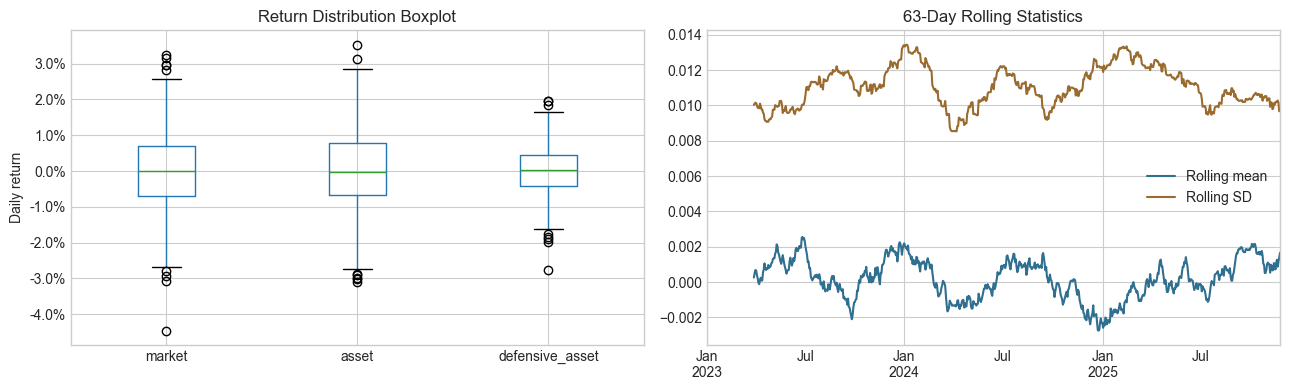

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
returns[["market", "asset", "defensive_asset"]].boxplot(ax=axes[0])
axes[0].set_title("Return Distribution Boxplot")
axes[0].set_ylabel("Daily return")
axes[0].yaxis.set_major_formatter(lambda x, pos: f"{x:.1%}")

asset.rolling(63).mean().plot(ax=axes[1], color="#2f6f8f", label="Rolling mean")
asset.rolling(63).std().plot(ax=axes[1], color="#9a6b2f", label="Rolling SD")
axes[1].set_title("63-Day Rolling Statistics")
axes[1].legend()
plt.tight_layout(); plt.show()

## 5. Application

Statistics is used to estimate expected returns, volatility, drawdowns, and whether a strategy result is stable enough to trust.

In [4]:
bootstrap_means = []
rng = np.random.default_rng(77)
for _ in range(2000):
    sample = rng.choice(asset.to_numpy(), size=len(asset), replace=True)
    bootstrap_means.append(sample.mean())

bootstrap_summary = pd.Series({
    "bootstrap_mean": np.mean(bootstrap_means),
    "bootstrap_ci_5pct": np.quantile(bootstrap_means, 0.05),
    "bootstrap_ci_95pct": np.quantile(bootstrap_means, 0.95),
})
bootstrap_summary.to_frame("value")

,value
bootstrap_mean,0.000270
bootstrap_ci_5pct,-0.000381
bootstrap_ci_95pct,0.000944


## 6. Reflection

- Sample estimates are uncertain.
- Confidence intervals make estimation uncertainty visible.
- Rolling statistics remind us that markets are not stable machines.
- Bootstrapping estimates uncertainty by resampling observed data.

Questions to answer after running the notebook:

1. Is the average daily return large relative to its standard error?
2. Why do rolling statistics change over time?
3. What does IQR tell you that standard deviation does not?
4. Why might bootstrapping still underestimate future uncertainty?